# Eksperyment: Wpływ funkcji straty na wyniki MLP

W tym notatniku zbadamy wpływ funkcji straty na proces uczenia modelu MLP.

Dla zadania klasyfikacji porównamy dwie funkcje straty: entropię krzyżową (cross-entropy) oraz błąd średniokwadratowy (MSE). Dla zadania regresji porównujemy MSE oraz MAE (Mean Absolute Error).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlp.mlp import MLP
from mlp.utils import (
    load_dataset, plot_dataset, plot_loss, plot_accuracy, train_test_split,
    plot_decision_boundary, plot_weights_together, accuracy, mse
)


In [2]:
# === 1. Konfiguracja ===

datasets = {
    # ======== KLASYFIKACJA ========
    "simple": {
        "path": "../lab1_data/Classification/data.simple.train.1000.csv",
        "task": "binary",
        "losses": ["mse", "binary_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
        "hidden_layers": [32, 32],
        "epochs": [50, 100],
    },
    "three_gauss": {
        "path": "../lab1_data/Classification/data.three_gauss.train.1000.csv",
        "task": "multiclass",
        "losses": ["mse", "categorical_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
        "hidden_layers": [32, 32],
        "epochs": [50, 100],
    },
    "xor": {
        "path": "../lab1_data/Classification/data.XOR.train.1000.csv",
        "task": "binary",
        "losses": ["mse", "binary_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
        "hidden_layers": [16, 16],
        "epochs": [50, 100],
    },
    "noisy_xor": {
        "path": "../lab1_data/Classification/data.noisyXOR.train.1000.csv",
        "task": "binary",
        "losses": ["mse", "binary_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
        "hidden_layers": [32, 32],
        "epochs": [50, 100],
    },
    "circles": {
        "path": "../lab1_data/Classification/data.circles.train.1000.csv",
        "task": "binary",
        "losses": ["mse", "binary_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
        "hidden_layers": [64, 64],
        "epochs": [50, 100],
    },

    # ======== REGRESJA ========
    "activation": {
        "path": "../lab1_data/Regression/data.activation.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [32, 32],
        "epochs": [50, 100],
    },
    "cube": {
        "path": "../lab1_data/Regression/data.cube.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [32, 32],
        "epochs": [50, 100],
    },
    "linear": {
        "path": "../lab1_data/Regression/data.linear.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [16],
        "epochs": [50, 100],
    },
    "square": {
        "path": "../lab1_data/Regression/data.square.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [32],
        "epochs": [50, 100],
    },
    "multimodal": {
        "path": "../lab1_data/Regression/data.multimodal.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [64, 64],
        "epochs": [50, 100],
    },
}

In [3]:
# === 2. Eksperyment główny ===
results = {}

for dataset_name, cfg in datasets.items():
    print(f"\n=== Dataset: {dataset_name.upper()} ===")
    X, y = load_dataset(cfg["path"])
    # plot_dataset(X, y, title=f"{dataset_name} dataset")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=42)

    results[dataset_name] = {}

    for loss in cfg["losses"]:
        for epoch_count in cfg["epochs"]:
            print(f"\n--- Training with loss: {loss} ({epoch_count} epochs) ---")
            model = MLP(
                layer_sizes=[X.shape[1], 32, 32, (1 if cfg["task"] != "multiclass" else len(np.unique(y)))],
                task=cfg["task"],
                activation=cfg["activation"],
                learning_rate=cfg["learning_rate"],
                loss=loss,
                seed=42
            )

            history, weight_history, acc_history = model.fit(X, y, epochs=epoch_count, verbose=False)
            results[dataset_name][loss] = {
                "model": model,
                "loss_history": history,
                "weight_history": weight_history,
                "acc_history": acc_history,
            }

            # --- Wizualizacje ---
            # plot_loss(history, title=f"Loss evolution ({dataset_name}, {loss})")
            # plot_weights_together(weight_history, title=f"Weight evolution ({dataset_name}, {loss})")

            if cfg["task"] in ["binary", "multiclass"]:
                preds = model.predict(X)
                acc_val = accuracy(y, preds)
                print(f"Final test accuracy ({loss}, {epoch_count} ep): {acc_val:.4f}")
                # plot_accuracy(acc_history, title=f"Accuracy evolution ({dataset_name}, {loss})")
                # plot_decision_boundary(model, X, y, title=f"Decision boundary ({dataset_name}, {loss})")
            else:
                y_pred = model.predict(X)
                mse_val = mse(y, y_pred)
                print(f"Final test MSE ({loss}, {epoch_count} ep): {mse_val:.4f}")


=== Dataset: SIMPLE ===

--- Training with loss: mse (50 epochs) ---
Final test accuracy (mse, 50 ep): 0.9470

--- Training with loss: mse (100 epochs) ---
Final test accuracy (mse, 100 ep): 0.9560

--- Training with loss: binary_cross_entropy (50 epochs) ---
Final test accuracy (binary_cross_entropy, 50 ep): 0.9010

--- Training with loss: binary_cross_entropy (100 epochs) ---
Final test accuracy (binary_cross_entropy, 100 ep): 0.9480

=== Dataset: THREE_GAUSS ===

--- Training with loss: mse (50 epochs) ---
Final test accuracy (mse, 50 ep): 0.7650

--- Training with loss: mse (100 epochs) ---
Final test accuracy (mse, 100 ep): 0.8830

--- Training with loss: categorical_cross_entropy (50 epochs) ---
Final test accuracy (categorical_cross_entropy, 50 ep): 0.8677

--- Training with loss: categorical_cross_entropy (100 epochs) ---
Final test accuracy (categorical_cross_entropy, 100 ep): 0.8887

=== Dataset: XOR ===

--- Training with loss: mse (50 epochs) ---
Final test accuracy (mse, 

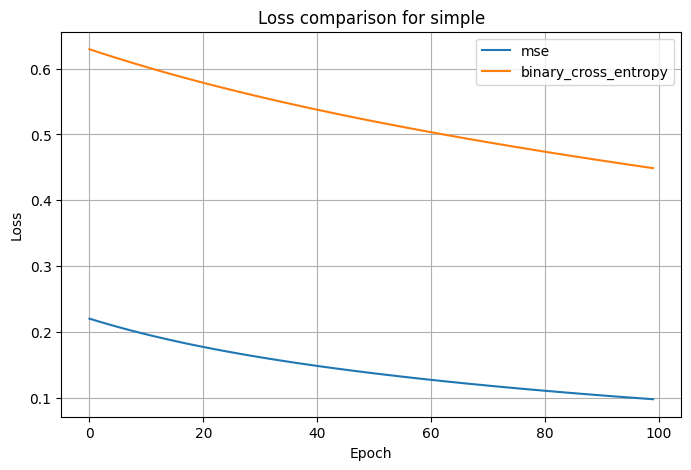

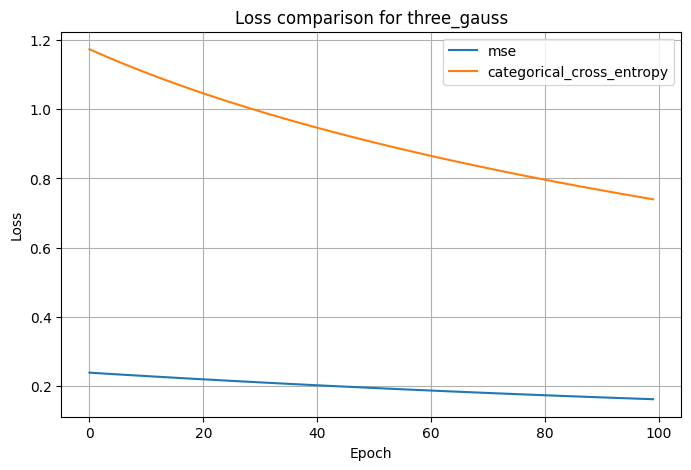

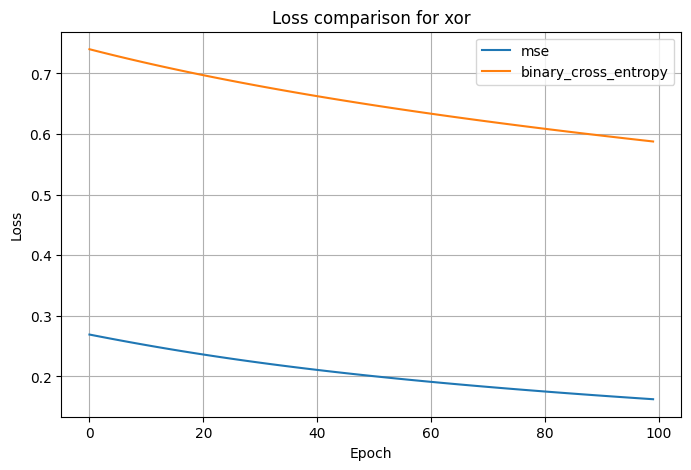

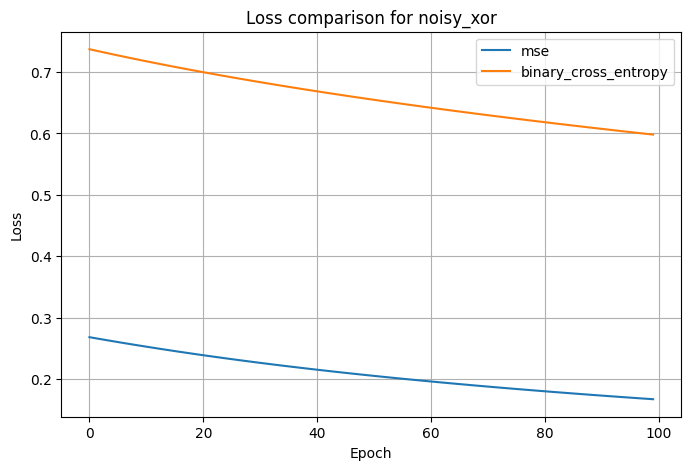

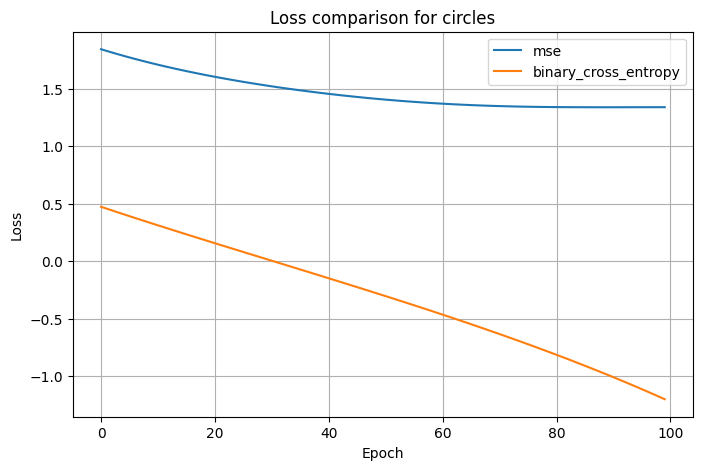

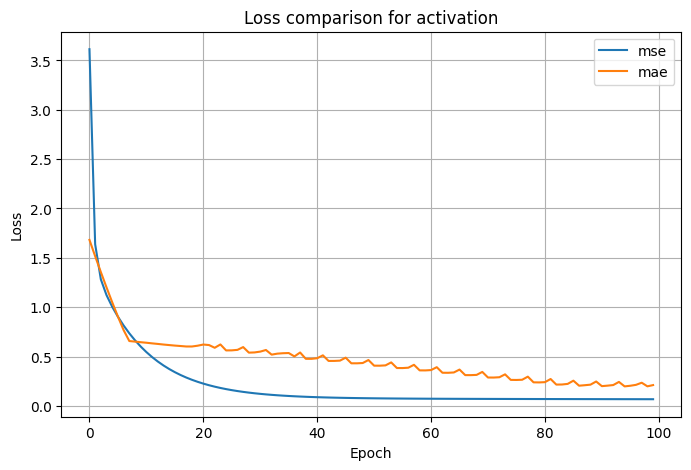

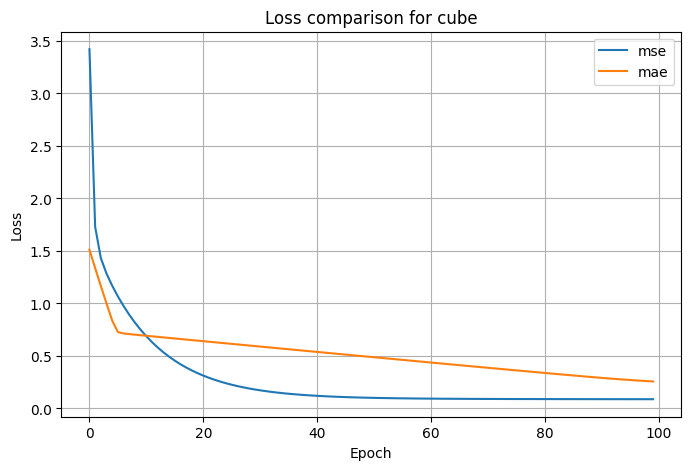

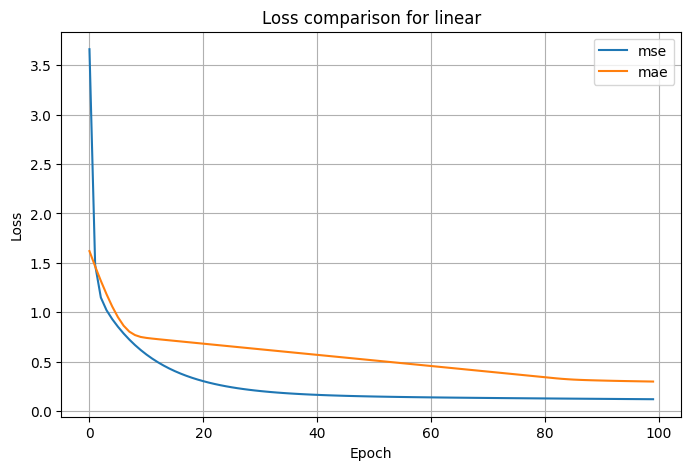

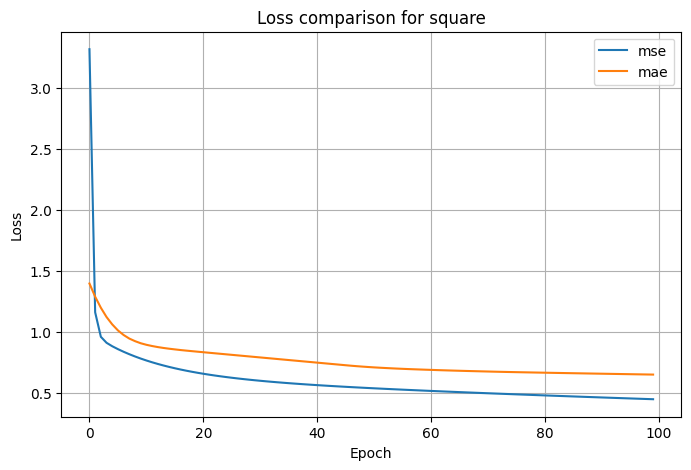

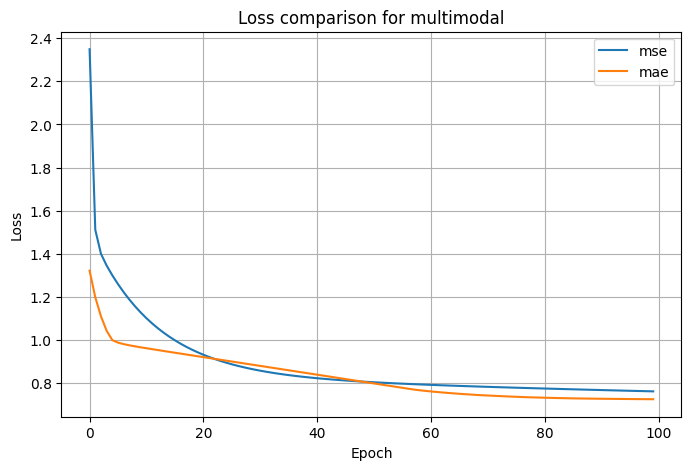

In [4]:
# === 3. Porównanie funkcji strat w obrębie zbioru ===
for dataset_name, res in results.items():
    plt.figure(figsize=(8, 5))
    for loss, data in res.items():
        plt.plot(data["loss_history"], label=loss)
    plt.title(f"Loss comparison for {dataset_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()